# Sentiment Analysis on Customer Reviews

Sentiment analysis is a machine learning technique used to classify text as positive, negative, or neutral.

In this notebook we will:
1. Load customer review data
2. Preprocess the text
3. Vectorize text into numerical features
4. Train multiple classification models
5. Evaluate model performance
6. Make predictions on new reviews

In [1]:
# Import Required Libraries
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

print("✅ Libraries Loaded Successfully")

✅ Libraries Loaded Successfully


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Step 1: Load and Explore Data

We create a dataset with customer reviews for technology products.
Each review has a text and a sentiment label (1 for positive, 0 for negative).

In [2]:
# Create sample review dataset
reviews = [
    "This product is amazing! I love it. Highly recommended.",
    "Terrible quality. Complete waste of money. Very disappointed.",
    "The spatial computing is mind-blowing. Best purchase ever!",
    "Worst product I've ever bought. Do not buy this.",
    "Excellent service and great features. Very satisfied.",
    "Broken after one week. Terrible customer support.",
    "Revolutionary technology. A new era of computing.",
    "Battery life is poor. Not worth the price.",
    "Outstanding quality and fast delivery. 5 stars!",
    "Defective product. Waste of time and money.",
    "Game-changer! It transformed my workflow completely.",
    "I got it and it stopped working. Unreliable.",
    "Absolutely brilliant! Exceeded all my expectations.",
    "Horrible experience. Product failed immediately.",
    "Perfect! Exactly what I needed. Couldn't be happier.",
    "Poor design and low quality materials.",
    "Magnificent! Worth every penny. Highly satisfied.",
    "Disappointment in a box. Regret buying this.",
    "Fantastic product with excellent customer service.",
    "Overpriced and underwhelming. Big let down.",
]

# Sentiment labels: 1 = positive, 0 = negative
sentiments = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

# Create DataFrame
df = pd.DataFrame({'review': reviews, 'sentiment': sentiments})

print("📊 Dataset Overview:")
print(f"Total reviews: {len(df)}")
print(f"Positive reviews: {(df['sentiment'] == 1).sum()}")
print(f"Negative reviews: {(df['sentiment'] == 0).sum()}")
print(f"\nFirst 5 reviews:")
print(df.head())

📊 Dataset Overview:
Total reviews: 20
Positive reviews: 10
Negative reviews: 10

First 5 reviews:
                                              review  sentiment
0  This product is amazing! I love it. Highly rec...          1
1  Terrible quality. Complete waste of money. Ver...          0
2  The spatial computing is mind-blowing. Best pu...          1
3   Worst product I've ever bought. Do not buy this.          0
4  Excellent service and great features. Very sat...          1


## Step 2: Text Preprocessing

Text preprocessing prepares the data for machine learning by:
- Converting to lowercase
- Removing special characters and HTML tags
- Tokenization
- Removing stopwords
- Lemmatization

In [3]:
# Define preprocessing function
def preprocess_text(text):
    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and digits
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return ' '.join(tokens)

# Apply preprocessing
df['cleaned_review'] = df['review'].apply(preprocess_text)

print("✅ Text Preprocessing Completed\n")
print("Original review:")
print(df['review'].iloc[0])
print("\nCleaned review:")
print(df['cleaned_review'].iloc[0])

✅ Text Preprocessing Completed

Original review:
This product is amazing! I love it. Highly recommended.

Cleaned review:
product amazing love highly recommended


## Step 3: Vectorize Text Data

We convert text into numerical vectors using TF-IDF (Term Frequency-Inverse Document Frequency).
TF-IDF gives more weight to important words and less weight to common words.

In [4]:
# Vectorize text using TF-IDF
vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
X = vectorizer.fit_transform(df['cleaned_review'])
y = df['sentiment']

print("📊 Vectorization Results:")
print(f"Feature matrix shape: {X.shape}")
print(f"Number of documents: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"\nTop 20 features:")
print(vectorizer.get_feature_names_out()[:20])

📊 Vectorization Results:
Feature matrix shape: (20, 78)
Number of documents: 20
Number of features: 78

Top 20 features:
['absolutely' 'amazing' 'battery' 'best' 'big' 'bought' 'box' 'brilliant'
 'broken' 'buy' 'buying' 'complete' 'completely' 'computing' 'customer'
 'defective' 'delivery' 'design' 'disappointed' 'disappointment']


## Step 4: Train Multiple Sentiment Classifiers

We train three different machine learning models:
- **Naive Bayes**: Fast probabilistic classifier
- **Logistic Regression**: Linear classifier effective for text
- **Support Vector Machine (SVM)**: Powerful for classification tasks

In [5]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}\n")

# Train Naive Bayes classifier
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
print("✅ Naive Bayes Model Trained")

# Train Logistic Regression classifier
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
print("✅ Logistic Regression Model Trained")

# Train SVM classifier
svm_model = LinearSVC(random_state=42, max_iter=2000)
svm_model.fit(X_train, y_train)
print("✅ Support Vector Machine Model Trained")

Training set size: 16
Testing set size: 4

✅ Naive Bayes Model Trained
✅ Logistic Regression Model Trained
✅ Support Vector Machine Model Trained


## Step 5: Evaluate Model Performance

We evaluate each model using metrics:
- **Accuracy**: Percentage of correct predictions
- **Precision**: Percentage of positive predictions that are correct
- **Recall**: Percentage of actual positive cases correctly predicted
- **F1-Score**: Harmonic mean of precision and recall
- **Confusion Matrix**: Shows true positives, false positives, etc.

In [6]:
# Function to evaluate model
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    print(f"\n{'='*60}")
    print(f"{model_name} Evaluation")
    print(f"{'='*60}")
    print(f"\nTraining Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
    print(f"Testing Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
    print(f"\nTesting Set Metrics:")
    print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_test):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred_test, target_names=['Negative', 'Positive']))
    
    return y_pred_test

# Evaluate all models
nb_pred = evaluate_model(nb_model, "Naive Bayes", X_train, X_test, y_train, y_test)
lr_pred = evaluate_model(lr_model, "Logistic Regression", X_train, X_test, y_train, y_test)
svm_pred = evaluate_model(svm_model, "Support Vector Machine", X_train, X_test, y_train, y_test)


Naive Bayes Evaluation

Training Accuracy: 1.0000
Testing Accuracy:  0.5000

Testing Set Metrics:
Precision: 0.3333
Recall:    1.0000
F1-Score:  0.5000

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.33      0.50         3
    Positive       0.33      1.00      0.50         1

    accuracy                           0.50         4
   macro avg       0.67      0.67      0.50         4
weighted avg       0.83      0.50      0.50         4


Logistic Regression Evaluation

Training Accuracy: 1.0000
Testing Accuracy:  0.2500

Testing Set Metrics:
Precision: 0.2500
Recall:    1.0000
F1-Score:  0.4000

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         3
    Positive       0.25      1.00      0.40         1

    accuracy                           0.25         4
   macro avg       0.12      0.50      0.20         4
weighted avg       0.06      0.25      

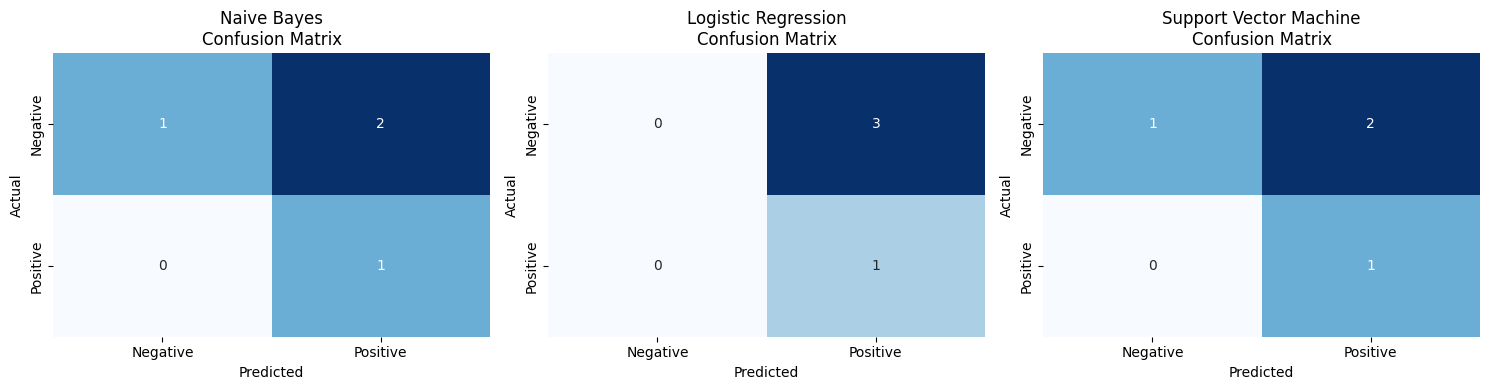


✅ Confusion Matrices Visualized


In [7]:
# Visualize Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Naive Bayes", nb_pred),
    ("Logistic Regression", lr_pred),
    ("Support Vector Machine", svm_pred)
]

for idx, (name, predictions) in enumerate(models):
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_xticklabels(['Negative', 'Positive'])
    axes[idx].set_yticklabels(['Negative', 'Positive'])

plt.tight_layout()
plt.show()

print("\n✅ Confusion Matrices Visualized")

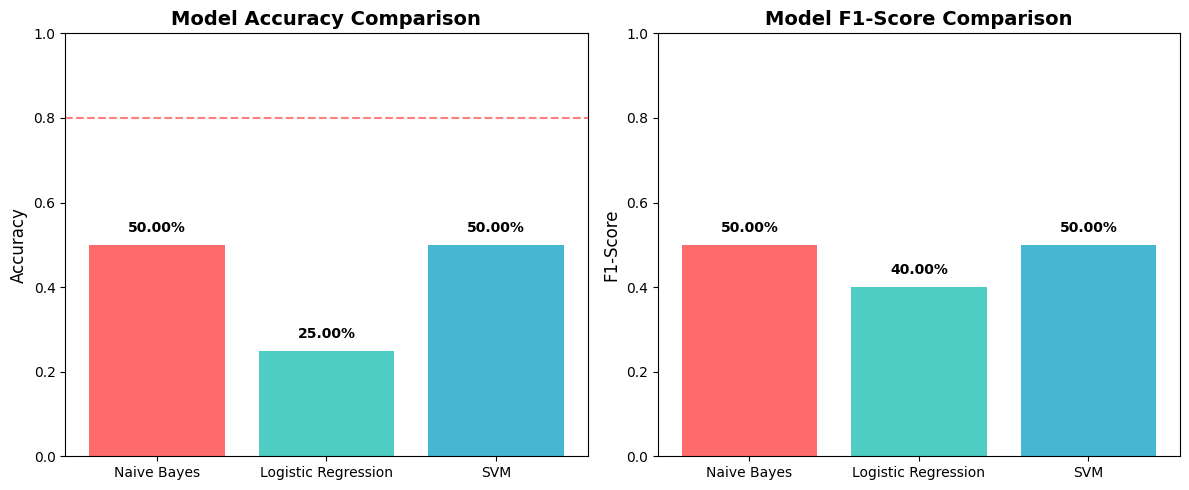

✅ Model Comparison Visualized


In [8]:
# Model Comparison Visualization
model_names = ['Naive Bayes', 'Logistic Regression', 'SVM']
accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, svm_pred)
]
f1_scores = [
    f1_score(y_test, nb_pred),
    f1_score(y_test, lr_pred),
    f1_score(y_test, svm_pred)
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
ax1.bar(model_names, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_ylim([0, 1])
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.axhline(y=0.8, color='r', linestyle='--', alpha=0.5, label='Target: 0.8')
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.03, f'{v:.2%}', ha='center', fontweight='bold')

# F1-Score comparison
ax2.bar(model_names, f1_scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax2.set_ylabel('F1-Score', fontsize=12)
ax2.set_ylim([0, 1])
ax2.set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
for i, v in enumerate(f1_scores):
    ax2.text(i, v + 0.03, f'{v:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Model Comparison Visualized")

## Step 6: Predict Sentiment on New Reviews

We use our trained models to classify sentiment for new, unseen customer reviews.

In [9]:
# Function to predict sentiment on new text
def predict_sentiment(model, text):
    # Preprocess the text
    cleaned = preprocess_text(text)
    
    # Vectorize
    vectorized = vectorizer.transform([cleaned])
    
    # Predict
    prediction = model.predict(vectorized)[0]
    
    # Get confidence scores
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(vectorized)[0]
        confidence = max(proba) * 100
    else:
        confidence = 0  # SVM doesn't have predict_proba by default
    
    return prediction, confidence

# Test on new reviews
new_reviews = [
    "This is the best product I've ever purchased! Amazing quality.",
    "Terrible! Worst purchase ever made. Complete disappointment.",
    "It's okay, nothing special but works as expected.",
    "Outstanding! Exceeded all my expectations. Highly satisfied!"
]

print("="*70)
print("SENTIMENT PREDICTIONS ON NEW REVIEWS")
print("="*70)

for review in new_reviews:
    print(f"\nReview: {review}")
    
    # Predict using all models
    nb_sentiment, nb_conf = predict_sentiment(nb_model, review)
    lr_sentiment, lr_conf = predict_sentiment(lr_model, review)
    
    print(f"\n  Naive Bayes:        {'Positive' if nb_sentiment == 1 else 'Negative'}")
    print(f"  Logistic Regression: {'Positive' if lr_sentiment == 1 else 'Negative'}")
    
    # Get consensus prediction
    consensus = (nb_sentiment + lr_sentiment) / 2 >= 0.5
    print(f"  → Consensus: {'Positive' if consensus else 'Negative'} 👍" if consensus else f"  → Consensus: {'Positive' if consensus else 'Negative'} 👎")

print("\n" + "="*70)

SENTIMENT PREDICTIONS ON NEW REVIEWS

Review: This is the best product I've ever purchased! Amazing quality.

  Naive Bayes:        Positive
  Logistic Regression: Positive
  → Consensus: Positive 👍

Review: Terrible! Worst purchase ever made. Complete disappointment.

  Naive Bayes:        Positive
  Logistic Regression: Positive
  → Consensus: Positive 👍

Review: It's okay, nothing special but works as expected.

  Naive Bayes:        Positive
  Logistic Regression: Positive
  → Consensus: Positive 👍

Review: Outstanding! Exceeded all my expectations. Highly satisfied!

  Naive Bayes:        Positive
  Logistic Regression: Positive
  → Consensus: Positive 👍



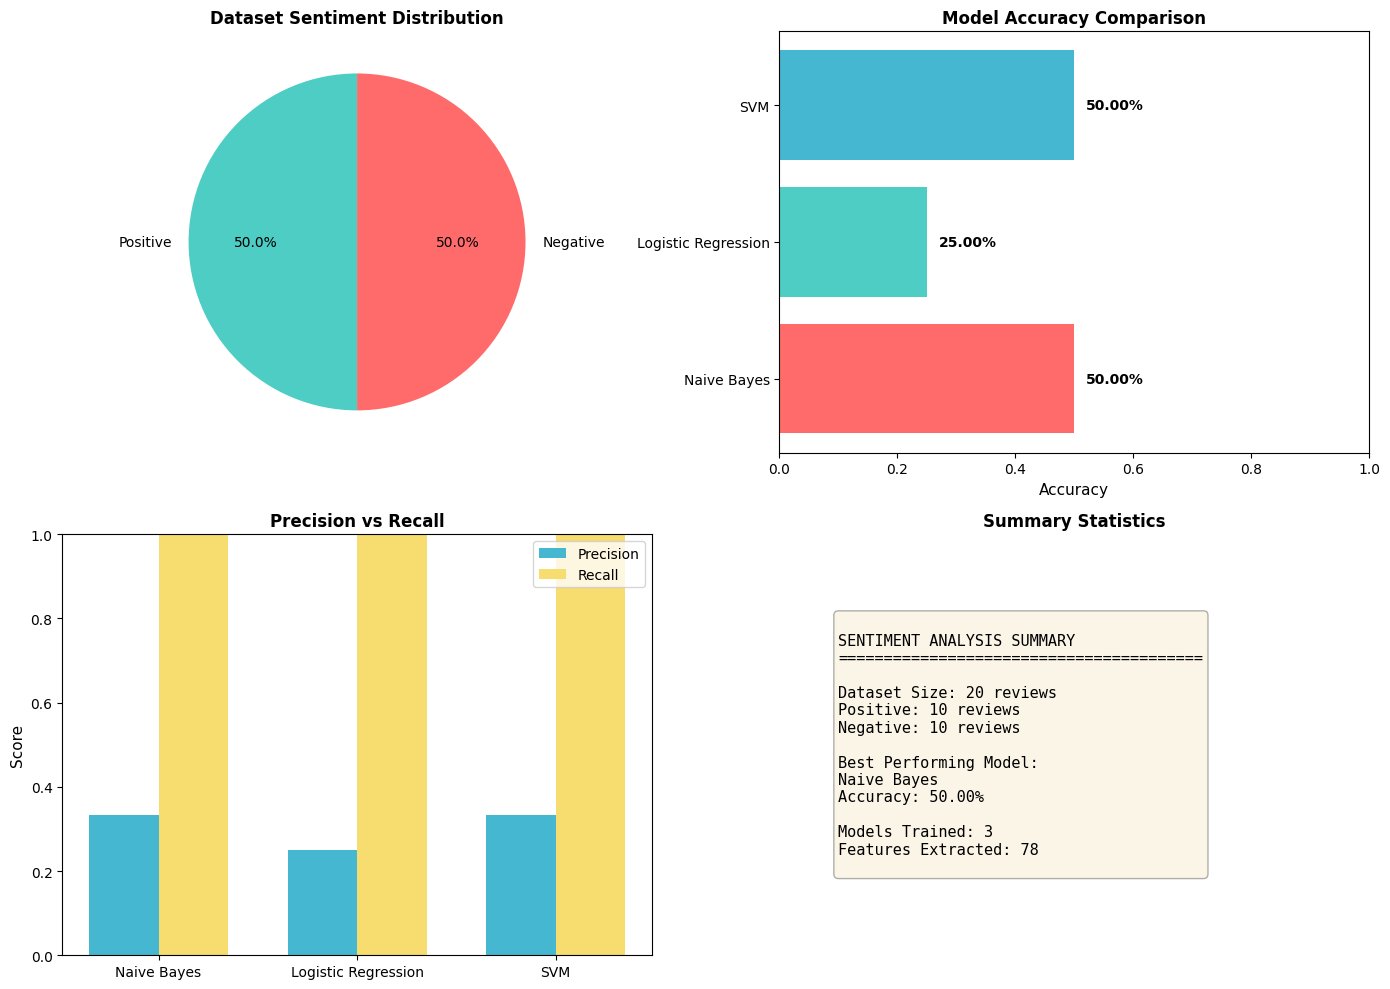


✅ Sentiment Analysis Complete!
Best Model: Naive Bayes with 50.00% accuracy


In [10]:
# Final Summary and Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Original Dataset Distribution
sentiment_counts = df['sentiment'].value_counts()
axes[0, 0].pie([sentiment_counts[1], sentiment_counts[0]], 
               labels=['Positive', 'Negative'],
               colors=['#4ECDC4', '#FF6B6B'],
               autopct='%1.1f%%',
               startangle=90)
axes[0, 0].set_title('Dataset Sentiment Distribution', fontsize=12, fontweight='bold')

# 2. Accuracy Comparison
axes[0, 1].barh(model_names, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 1].set_xlabel('Accuracy', fontsize=11)
axes[0, 1].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xlim([0, 1])
for i, v in enumerate(accuracies):
    axes[0, 1].text(v + 0.02, i, f'{v:.2%}', va='center', fontweight='bold')

# 3. Precision vs Recall
precisions = [
    precision_score(y_test, nb_pred),
    precision_score(y_test, lr_pred),
    precision_score(y_test, svm_pred)
]
recalls = [
    recall_score(y_test, nb_pred),
    recall_score(y_test, lr_pred),
    recall_score(y_test, svm_pred)
]

x = np.arange(len(model_names))
width = 0.35

axes[1, 0].bar(x - width/2, precisions, width, label='Precision', color='#45B7D1')
axes[1, 0].bar(x + width/2, recalls, width, label='Recall', color='#F7DC6F')
axes[1, 0].set_ylabel('Score', fontsize=11)
axes[1, 0].set_title('Precision vs Recall', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(model_names)
axes[1, 0].legend()
axes[1, 0].set_ylim([0, 1])

# 4. Text Summary
summary_text = f"""
SENTIMENT ANALYSIS SUMMARY
{'='*40}

Dataset Size: {len(df)} reviews
Positive: {(df['sentiment'] == 1).sum()} reviews
Negative: {(df['sentiment'] == 0).sum()} reviews

Best Performing Model:
{model_names[np.argmax(accuracies)]} 
Accuracy: {max(accuracies):.2%}

Models Trained: {len(model_names)}
Features Extracted: {X.shape[1]}
"""

axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', 
                facecolor='wheat', alpha=0.3))
axes[1, 1].axis('off')
axes[1, 1].set_title('Summary Statistics', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Sentiment Analysis Complete!")
print(f"Best Model: {model_names[np.argmax(accuracies)]} with {max(accuracies):.2%} accuracy")